In [81]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import r2_score




In [82]:
df = pd.read_csv('Ice_cream selling data.csv')

In [83]:
# Input and Output
X = df[['Temperature (°C)']]
y = df['Ice Cream Sales (units)']

In [84]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [85]:
# Correlation
print(df.corr())


                         Temperature (°C)  Ice Cream Sales (units)
Temperature (°C)                 1.000000                -0.175184
Ice Cream Sales (units)         -0.175184                 1.000000


In [86]:
# Model
model = LinearRegression()
model.fit(X_train, y_train)




,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[-1.15]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Temperature (°C)']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,17.14
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [87]:
y_pred = model.predict(X_test)

In [88]:
# Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

In [89]:
print("MAE =", mae)
print("RMSE =", rmse)

MAE = 11.752026695440602
RMSE = 12.219913714640208


In [90]:
import matplotlib.pyplot as plt

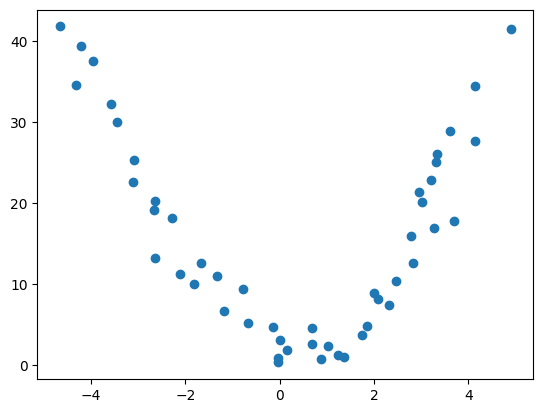

In [91]:
plt.scatter(X, y)
plt.show()

# conclusion 
# the model provides resonable prediction but its accuracy is limited,indicating scope for further improvement

## polynomial feature

In [92]:
from sklearn.preprocessing import PolynomialFeatures


In [93]:
poly = PolynomialFeatures(degree=2)

In [94]:
updated_xtrain= poly.fit_transform(X_train)
updated_xtest= poly.transform(X_test)

In [95]:
model.fit(updated_xtrain,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[ 0. ,-0.71, 1.87]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.768
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,2
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](3,)","[38.94,17.19, 0. ]"


In [96]:
model.predict(updated_xtest)

array([10.24499852, 25.82807714, 31.8241041 , 24.61704203,  4.43380256,
        4.00785672,  3.58277491,  3.17865087,  7.86990452,  2.91591368])

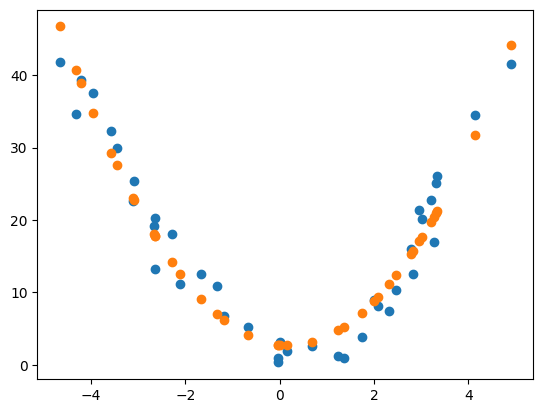

In [97]:
ypred_train = model.predict(updated_xtrain)
plt.scatter(updated_xtrain[ :,1],y_train)
plt.scatter(updated_xtrain[:,1],ypred_train)



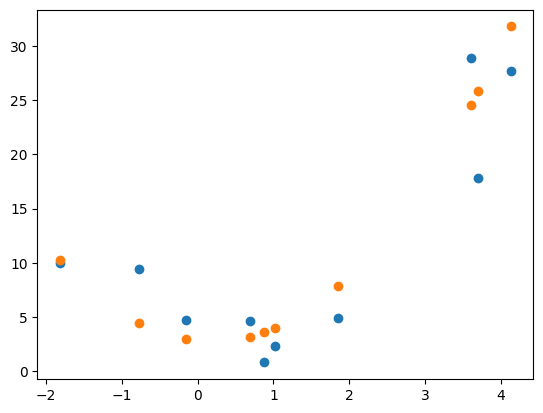

In [98]:
ypred_test = model.predict(updated_xtest)
plt.scatter(updated_xtest[ :,1],y_test)
plt.scatter(updated_xtest[:,1],ypred_test)

In [105]:
# test_score

y_test = model.predict(updated_xtest)
test_score = r2_score(y_test,ypred_test)
print(f"Test Score:  {test_score}")


Test Score:  1.0


In [108]:
# train_score

y_pred = model.predict(updated_xtrain)
test_score = r2_score(y_train,ypred_train)
print(f"Test Score:  {test_score}")



Test Score:  0.9413665676490518


Degree = 3, test score : 1.0
